In [1]:
from utils import get_svamp_df
from statistical_significance import compare_accuracies, compare_accuracies_v2, compare_accuracies_v3
import numpy as np
df = get_svamp_df("ReAct")

qwen3_1.7b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
llama3.2_1b.xlsx


# Misclassified

In [2]:
df_misc = get_svamp_df("ReAct", include_misclassified=True)
df_misc = df_misc[df_misc["Error Type"] == "Misclassified"]
df_misc.groupby(["Model", "Error Class"]).agg({
    "ID": "count",
}).reset_index().sort_values(by="ID", ascending=False).head(50)

qwen3_1.7b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
llama3.2_1b.xlsx


,Model,Error Class,ID
0,llama3.2:1b,Misclassified,14
2,qwen3:0.6b,Misclassified,10
1,qwen2.5:0.5b,Misclassified,9
3,qwen3:1.7b,Misclassified,4


In [3]:
overall_misc_rate = len(df_misc) / len(df)
print(f"Total misclassified examples: {len(df_misc)}")
print(f"Total examples: {len(df)}")
print(f"Overall misclassification rate: {overall_misc_rate:.2%}")

Total misclassified examples: 37
Total examples: 1136
Overall misclassification rate: 3.26%


# Accuracy

## Sorted

In [4]:
df_acc = df.groupby(["Model"]).agg({
    "is_correct": "mean",
}).reset_index().sort_values(by="is_correct", ascending=False)
df_acc

,Model,is_correct
3,qwen3:1.7b,0.961268
2,qwen3:0.6b,0.841549
0,llama3.2:1b,0.380282
1,qwen2.5:0.5b,0.338028


## Alphabetical

In [5]:
df_acc = df.groupby(["Model"]).agg({
    "is_correct": "mean",
}).reset_index().sort_values(by="Model", ascending=True)
df_acc

,Model,is_correct
0,llama3.2:1b,0.380282
1,qwen2.5:0.5b,0.338028
2,qwen3:0.6b,0.841549
3,qwen3:1.7b,0.961268


In [7]:
import pandas as pd
acc_records = df_acc.to_records()

n = df["ID"].nunique()
significant_results = []
for i in range(len(acc_records)):
    model1 = acc_records[i][1]
    score1 = acc_records[i][2]
    for j in range(i + 1, len(acc_records)):
        model2 = acc_records[j][1]
        score2 = acc_records[j][2]

        result = compare_accuracies_v3(score1, n, score2, n)
        if result.is_significant:
            significant_results.append((model1, model2, score1, score2, result.p_value, result.is_significant))

significant_results_df = pd.DataFrame([
    {
        'Model1': model1,
        'Model2': model2,
        'Score1': score1,
        'Score2': score2,
        'p_value': p_value,
        'is_significant': is_significant
    }
    for model1, model2, score1, score2, p_value, is_significant in significant_results
])
significant_results_df

,Model1,Model2,Score1,Score2,p_value,is_significant
0,llama3.2:1b,qwen3:0.6b,0.380282,0.841549,0.000000,True
1,llama3.2:1b,qwen3:1.7b,0.380282,0.961268,0.000000,True
2,qwen2.5:0.5b,qwen3:0.6b,0.338028,0.841549,0.000000,True
3,qwen2.5:0.5b,qwen3:1.7b,0.338028,0.961268,0.000000,True
4,qwen3:0.6b,qwen3:1.7b,0.841549,0.961268,0.000001,True


Interpretation

* llama3.2_1b and qwen2.5_0.5b perform worse than Qwen3 0.6B and Qwen3 1.7B
* Qwen3 0.6B performs significantly worse than Qwen3 1.7B

# Error Analysis

## Overview

In [8]:
df_err = df.groupby(["Model", "Error Type", "Error Class"]).agg({
    "ID": "count",
}).pivot_table(
    index=["Model"],
    columns=["Error Type", "Error Class"],
    values="ID",
    fill_value=0
).reset_index()

df_err.head(50)

Error Type          Model   Execution Error                                    \
Error Class               Calculation Error Loop Overthinking Wrong Reasoning   
0             llama3.2:1b               1.0  0.0          0.0           163.0   
1            qwen2.5:0.5b               1.0  1.0          1.0           158.0   
2              qwen3:0.6b               1.0  0.0          9.0            35.0   
3              qwen3:1.7b               0.0  0.0          4.0             7.0   

Error Type  Tool Error  
Error Class Tool Error  
0                 12.0  
1                 27.0  
2                  0.0  
3                  0.0

In [11]:
print(df_err.to_latex(index=False, caption='Anzahl der Fehlerarten und -klassen für SVAMP nach Modell', label='tab:error_types_svamp'))

\begin{table}
\caption{Anzahl der Fehlerarten und -klassen für SVAMP nach Modell}
\label{tab:error_types_svamp}
\begin{tabular}{lrrrrr}
\toprule
Model & \multicolumn{4}{r}{Execution Error} & Tool Error \\
 & Calculation Error & Loop & Overthinking & Wrong Reasoning & Tool Error \\
\midrule
llama3.2:1b & 1.000000 & 0.000000 & 0.000000 & 163.000000 & 12.000000 \\
qwen2.5:0.5b & 1.000000 & 1.000000 & 1.000000 & 158.000000 & 27.000000 \\
qwen3:0.6b & 1.000000 & 0.000000 & 9.000000 & 35.000000 & 0.000000 \\
qwen3:1.7b & 0.000000 & 0.000000 & 4.000000 & 7.000000 & 0.000000 \\
\bottomrule
\end{tabular}
\end{table}



## Plots

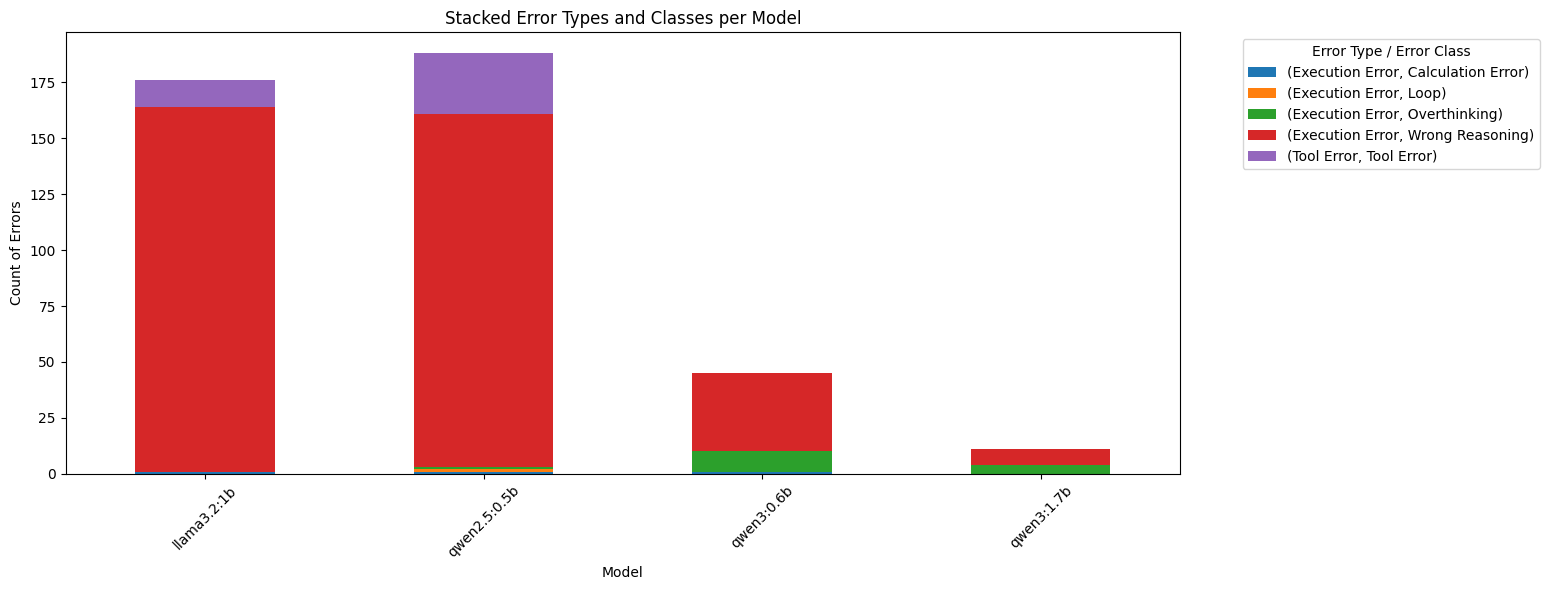

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Set index to "Model" to prepare for plotting
df_plot = df_err.set_index("Model")

# Plot as stacked bar chart
df_plot.plot(kind="bar", stacked=True, figsize=(12, 6))

plt.ylabel("Count of Errors")
plt.title("Stacked Error Types and Classes per Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title="Error Type / Error Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Per Operation Type

In [27]:
# Filter df by unique ids and collect number of unique question types
def get_question_type_mapping():
    seen_ids = set()
    question_type_mapping = {}
    for _, row in df.iterrows():
        if row['ID'] not in seen_ids:
            seen_ids.add(row['ID'])
            if row['Type'] not in question_type_mapping:
                question_type_mapping[row['Type']] = 0
            question_type_mapping[row['Type']] += 1
    return question_type_mapping

question_type_mapping = get_question_type_mapping()

# Convert to a DataFrame for better visualization
question_type_df = pd.DataFrame(list(question_type_mapping.items()), columns=['Question Type', 'Count'])
question_type_df = question_type_df.sort_values(by='Count', ascending=False)
question_type_df

,Question Type,Count
0,Subtraction,153
3,Addition,55
1,Common-Division,44
2,Multiplication,32


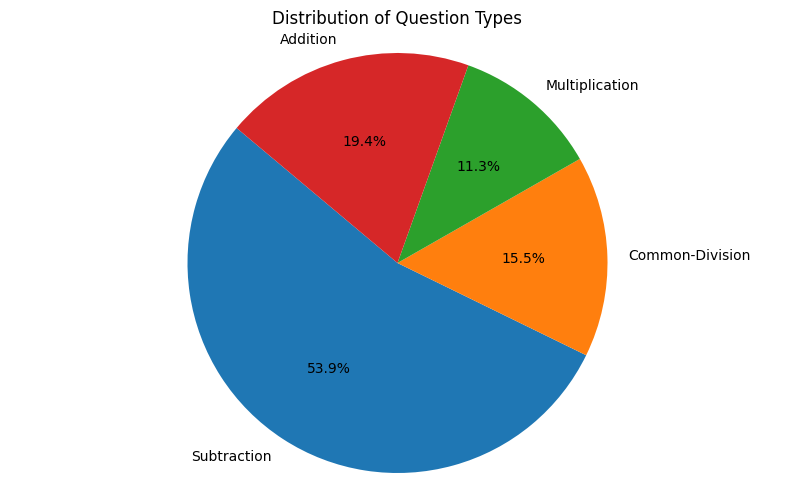

In [28]:
# Make a pie chart of the question types
import matplotlib.pyplot as plt
question_types = list(question_type_mapping.keys())
question_counts = list(question_type_mapping.values())
plt.figure(figsize=(10, 6))
plt.pie(question_counts, labels=question_types, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Question Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [29]:
qtypes_df = df.groupby(["Model", "Type"]).agg({
    "is_correct": "sum"
}).reset_index()

qtypes_df["Total_Questions"] = qtypes_df["Type"].map(lambda x: question_type_mapping.get(x, 0))
qtypes_df["Correct_Score"] = qtypes_df["is_correct"] / qtypes_df["Total_Questions"] * 100

# Pivot the DataFrame to get question types as rows and models as columns
qtypes_pivot = qtypes_df.pivot_table(index='Type', columns='Model', values='Correct_Score', fill_value=0)
qtypes_pivot

/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_62785/4148216791.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  qtypes_pivot = qtypes_df.pivot_table(index='Type', columns='Model', values='Correct_Score', fill_value=0)


Model,ollama/llama3.2_1b,ollama/qwen2.5_0.5b,ollama/qwen3_0.6b,ollama/qwen3_1.7b
Type,,,,
Addition,43.636364,32.727273,89.090909,92.727273
Common-Division,38.636364,54.545455,70.454545,93.181818
Multiplication,25.000000,37.500000,81.250000,93.750000
Subtraction,38.562092,27.450980,86.928105,98.692810


In [30]:
qtypes_dict = qtypes_pivot.to_dict()
significant_results = {}
for model, scores in qtypes_dict.items():
    items = list(scores.items())
    significant_results[model] = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            item1, item2 = items[i], items[j]
            p1 = item1[1]/100
            p2 = item2[1]/100
            n1 = question_type_mapping.get(item1[0], 0)
            n2 = question_type_mapping.get(item2[0], 0)
            if n1 == 0 or n2 == 0:
                raise ValueError(f"Question type '{item1[0]}' or '{item2[0]}' not found in mapping.")
            result = compare_accuracies_v3(p1, n1, p2, n2)
            if result.is_significant:
                significant_results[model].append((item1[0], item1[1], item2[0], item2[1], result.p_value, result.is_significant))

significant_results_df = pd.DataFrame([
    {
        'Model': model,
        'Type1': item[0],
        'Score1': item[1],
        'Type2': item[2],
        'Score2': item[3],
        'p_value': item[4],
        'is_significant': item[5]
    }
    for model, items in significant_results.items()
    for item in items
])
significant_results_df

,Model,Type1,Score1,Type2,Score2,p_value,is_significant
0,ollama/qwen2.5_0.5b,Addition,32.727273,Common-Division,54.545455,0.026254,True
1,ollama/qwen2.5_0.5b,Common-Division,54.545455,Subtraction,27.450980,0.001141,True
2,ollama/qwen3_0.6b,Addition,89.090909,Common-Division,70.454545,0.020783,True
3,ollama/qwen3_0.6b,Common-Division,70.454545,Subtraction,86.928105,0.025971,True


Interpretation:

* **Qwen2.5:0.5B**: performs significantly better on *Common-Division* than on *Addition* or *Subtraction*
* **ollama/qwen3_0.6b**: performs significantly worse on *Common-Division* than on *Addition* or *Subtraction*



## Question Type

In [31]:
# Different question types
def classify_question_type(question):
    if "how many more" in question.lower():
        return "How Many More"
    elif "how many" in question.lower():
        return "How Many"
    elif "how much" in question.lower():
        return "How Much"
    elif "how big" in question.lower():
        return "How Big"
    elif "how long" in question.lower():
        return "How Long"
    elif "what is" in question.lower():
        return "What is"
    elif "how deep" in question.lower():
        return "How Deep"
    elif "how far" in question.lower():
        return "How Far"
    return np.nan

df_qt = df.copy()
df_qt['Question_Type'] = df['Question-only'].apply(classify_question_type)
print("NAN Question Types:", df_qt['Question_Type'].isna().sum())

# show ten questions with NaN question types
for question in df_qt[df_qt['Question_Type'].isna()]['question']:
    print(question)

# Filter df by unique ids and collect number of unique question types
def get_question_type_mapping():
    seen_ids = set()
    question_type_mapping = {}
    for _, row in df_qt.iterrows():
        if row['ID'] not in seen_ids:
            seen_ids.add(row['ID'])
            if row['Question_Type'] not in question_type_mapping:
                question_type_mapping[row['Question_Type']] = 0
            question_type_mapping[row['Question_Type']] += 1
    return question_type_mapping

question_type_mapping = get_question_type_mapping()

question_type_df = pd.DataFrame(list(question_type_mapping.items()), columns=['Question Type', 'Count'])
question_type_df = question_type_df.sort_values(by='Count', ascending=False)
question_type_df

NAN Question Types: 0


,Question Type,Count
1,How Many,166
0,How Many More,75
2,How Much,33
3,How Big,3
4,What is,2
5,How Long,2
7,How Far,2
6,How Deep,1


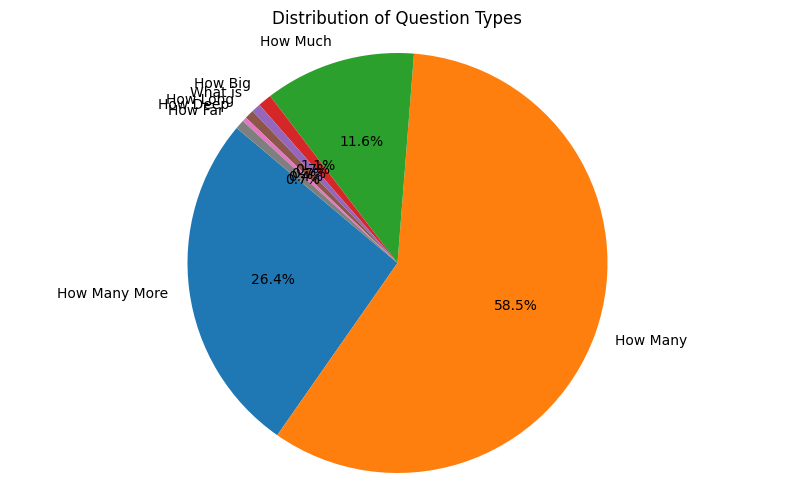

In [32]:
# Make a pie chart of the question types
import matplotlib.pyplot as plt
question_types = list(question_type_mapping.keys())
question_counts = list(question_type_mapping.values())
plt.figure(figsize=(10, 6))
plt.pie(question_counts, labels=question_types, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Question Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [33]:
qtypes_df = df_qt.groupby(["Model", "Question_Type"]).agg({
    "is_correct": "sum"
}).reset_index()

qtypes_df["Total_Questions"] = qtypes_df["Question_Type"].map(lambda x: question_type_mapping.get(x, 0))
qtypes_df["Correct_Score"] = qtypes_df["is_correct"] / qtypes_df["Total_Questions"] * 100
qtypes_pivot = qtypes_df.pivot_table(index='Question_Type', columns='Model', values='Correct_Score', fill_value=0)
qtypes_pivot

/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_62785/3781238049.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  qtypes_pivot = qtypes_df.pivot_table(index='Question_Type', columns='Model', values='Correct_Score', fill_value=0)


Model,ollama/llama3.2_1b,ollama/qwen2.5_0.5b,ollama/qwen3_0.6b,ollama/qwen3_1.7b
Question_Type,,,,
How Big,0.000000,66.666667,66.666667,100.000000
How Deep,0.000000,0.000000,100.000000,100.000000
How Far,0.000000,0.000000,100.000000,100.000000
How Long,50.000000,50.000000,100.000000,100.000000
How Many,43.373494,42.771084,84.337349,95.783133
How Many More,32.000000,16.000000,88.000000,100.000000
How Much,33.333333,27.272727,72.727273,87.878788
What is,0.000000,50.000000,100.000000,100.000000


In [34]:
qtypes_dict = qtypes_pivot.to_dict()
significant_results = {}
for model, scores in qtypes_dict.items():
    items = list(scores.items())
    significant_results[model] = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            item1, item2 = items[i], items[j]
            p1 = item1[1]/100
            p2 = item2[1]/100
            n1 = question_type_mapping.get(item1[0], 0)
            n2 = question_type_mapping.get(item2[0], 0)
            
            if n1 == 0 or n2 == 0:
                raise ValueError(f"Question type '{item1[0]}' or '{item2[0]}' not found in mapping.")
            result = compare_accuracies_v3(p1, n1, p2, n2)
            if result.is_significant:
                significant_results[model].append((item1[0], item1[1], item2[0], item2[1], result.p_value, result.is_significant))
                print(f"Comparing {p1} (n={n1}) with {p2} (n={n2}) for model {model}")

significant_results_df = pd.DataFrame([
    {
        'Model': model,
        'Type1': item[0],
        'Score1': item[1],
        'Type2': item[2],
        'Score2': item[3],
        'p_value': item[4],
        'is_significant': item[5]
    }
    for model, items in significant_results.items()
    for item in items
])
significant_results_df.head(10)

Comparing 0.4277108433734939 (n=166) with 0.16 (n=75) for model ollama/qwen2.5_0.5b
Comparing 0.9578313253012049 (n=166) with 1.0 (n=75) for model ollama/qwen3_1.7b
Comparing 1.0 (n=75) with 0.8787878787878788 (n=33) for model ollama/qwen3_1.7b


,Model,Type1,Score1,Type2,Score2,p_value,is_significant
0,ollama/qwen2.5_0.5b,How Many,42.771084,How Many More,16.000000,0.000003,True
1,ollama/qwen3_1.7b,How Many,95.783133,How Many More,100.000000,0.006864,True
2,ollama/qwen3_1.7b,How Many More,100.000000,How Much,87.878788,0.032886,True


Interpretation

- **Qwen 2.5 0.5B**: Performs much worse on *How many more* than on *how many*
- **Qwen 3 1.7B**: Performs slightly but significantly worse on *How many* and *How much* than on *how many more*


# Tool Usage

In [13]:
df_tool = df.copy()
df_tool['Tool_Counter'] = df_tool['reasoning'].apply(lambda x: x.count('[TOOL]:'))
df_tool['Tool_Used'] = df_tool['Tool_Counter'] > 0

df_tool.groupby(['Model']).agg({
    'Tool_Counter': 'sum',
    'Tool_Used': 'mean',
    'is_correct': 'mean'
})

,Tool_Counter,Tool_Used,is_correct
Model,,,
llama3.2:1b,278,0.975352,0.380282
qwen2.5:0.5b,275,0.929577,0.338028
qwen3:0.6b,17,0.059859,0.841549
qwen3:1.7b,196,0.665493,0.961268


In [14]:
# Check if tool was used if it was correct
df_tool.groupby(['Model', "Tool_Used"]).agg({
    'is_correct': ['mean', "count"]
})

is_correct      
                             mean count
Model        Tool_Used                 
llama3.2:1b  False            0.0     7
             True        0.389892   277
qwen2.5:0.5b False           0.55    20
             True         0.32197   264
qwen3:0.6b   False       0.846442   267
             True        0.764706    17
qwen3:1.7b   False       0.957895    95
             True        0.962963   189

In [19]:
# Check if tool was used if it was correct
df_tool.groupby(['Model', "Tool_Used"]).agg({
    'is_correct': 'mean'
}).pivot_table(
    index='Model',
    columns='Tool_Used',
    values='is_correct',
    fill_value=0
).reset_index()

/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_14185/2647746650.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  }).pivot_table(


Tool_Used,Model,False,True
0,llama3.2:1b,0.000000,0.389892
1,qwen2.5:0.5b,0.550000,0.321970
2,qwen3:0.6b,0.846442,0.764706
3,qwen3:1.7b,0.957895,0.962963


In [18]:
# Check if tool was used if it was correct
print(df_tool.groupby(['Model', "Tool_Used"]).agg({
    'is_correct': 'mean'
}).pivot_table(
    index='Model',
    columns='Tool_Used',
    values='is_correct',
    fill_value=0
).reset_index().to_latex(index=False, caption='Anzahl der korrekten Antworten bei Nutzung des Tools für SVAMP nach Modell', label='tab:correct_tool_usage_svamp'))

\begin{table}
\caption{Anzahl der korrekten Antworten bei Nutzung des Tools für SVAMP nach Modell}
\label{tab:correct_tool_usage_svamp}
\begin{tabular}{lrr}
\toprule
Model & False & True \\
\midrule
llama3.2:1b & 0.000000 & 0.389892 \\
qwen2.5:0.5b & 0.550000 & 0.321970 \\
qwen3:0.6b & 0.846442 & 0.764706 \\
qwen3:1.7b & 0.957895 & 0.962963 \\
\bottomrule
\end{tabular}
\end{table}



/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_14185/2024579015.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  }).pivot_table(


In [51]:
compare_accuracies_v3(0, 7, 0.389, 277)

AccuracyComparisonResult(z_score=nan, p_value=np.float64(0.04680407852687322), is_significant=np.True_, min_required_delta=nan)

Interpretation

* **Llama** and **Qwen 2.5 0.5B** almost always use Tools but perform significantly worse than the Qwen3 models
* **Qwen 2.5 0.B** performs significantly better without tools whereas **Llama** performs significantly worse with tools (although count is little for no-tool-usage)
* **Qwen3 0.6B** uses almost no tools and performs with tools insignificantly worse
* **Qwen3 1.7B** uses twice as often tools but achieves comparable performance regardless of tool usage.